# View All Output Photos

This notebook finds and displays all image files in this folder and all subfolders.

---

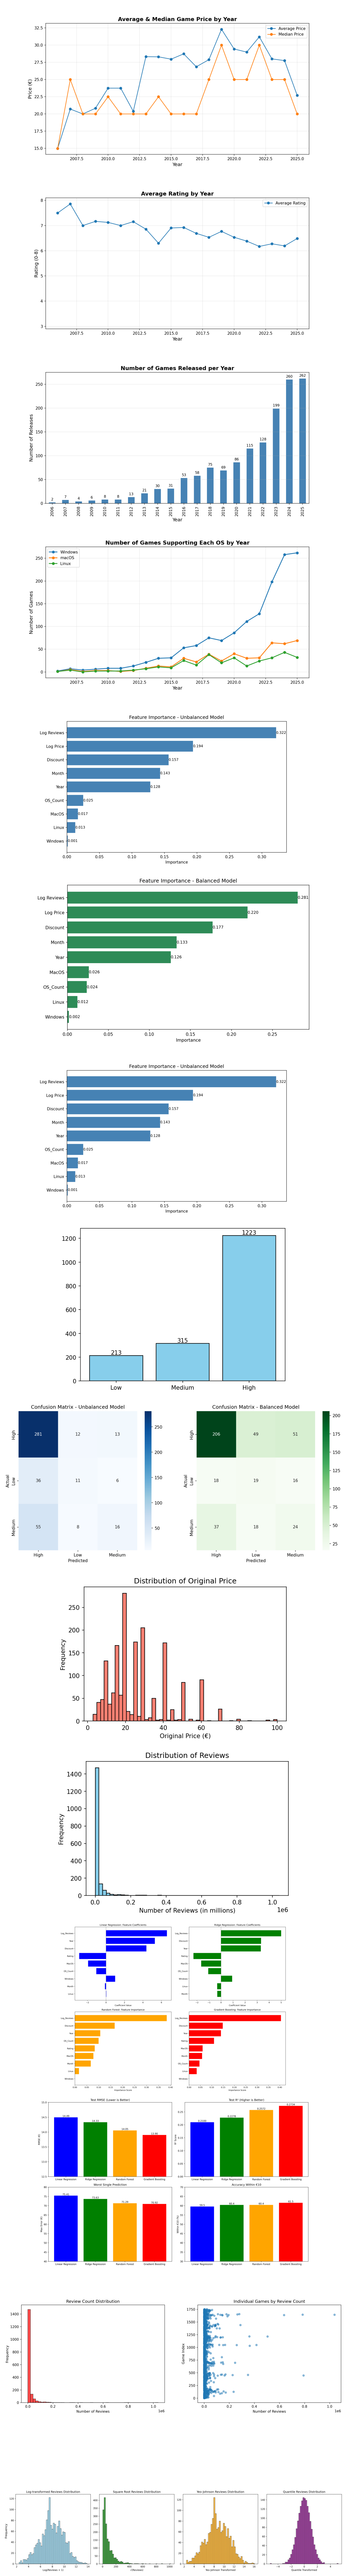

In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

root = Path.cwd()
image_exts = {'.png', '.jpg', '.jpeg', '.gif', '.webp', '.bmp', '.tif', '.tiff'}

image_files = sorted(
    p for p in root.rglob('*')
    if p.is_file() and p.suffix.lower() in image_exts
)

if not image_files:
    print('No images found. Add photos in this folder/subfolders, then rerun.')
else:
    max_images = 15
    display_files = image_files[:max_images]

    rows = max_images
    cols = 1
    fig, axes = plt.subplots(rows, cols, figsize=(12, 6 * rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax in axes:
        ax.axis('off')

    for idx, img_path in enumerate(display_files):
        ax = axes[idx]
        try:
            with Image.open(img_path) as img:
                ax.imshow(img.convert('RGB'))
        except Exception as e:
            ax.text(0.5, 0.5, f'Cannot open\n{img_path.name}\n{e}', ha='center', va='center')
        ax.axis('off')

    plt.tight_layout()
    plt.show()